In [1]:
pip install numpy pandas matplotlib scikit-learn pillow pyproj scipy joblib tqdm seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Imports and configuration

In [1]:
import os, glob
import numpy as np
import pandas as pd
from PIL import Image
from pyproj import Transformer, Geod
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import timedelta

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error
from imblearn.under_sampling import ClusterCentroids

In [11]:
from osgeo import gdal

def load_dem(path):
    """
    Carrega um Modelo Digital de Elevação (DEM) e retorna:
    - dem: matriz NumPy com a elevação (em metros)
    - extent: (lon_min, lon_max, lat_min, lat_max)
    """
    if not path.exists():
        raise FileNotFoundError(f'DEM nao encontrado: {path}. Rode "eio clip" para gerar.')

    ds = gdal.Open(str(path))
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    gt = ds.GetGeoTransform()
    minx, pixel_w, _, maxy, _, pixel_h = gt
    maxx = minx + pixel_w * ds.RasterXSize
    miny = maxy + pixel_h * ds.RasterYSize
    extent = (minx, maxx, miny, maxy)

    return arr, extent, abs(pixel_w), abs(pixel_h)

In [12]:
from pathlib import Path

DEM_FILE = Path("../../notebooks/sumare_radar/RJ-30m-DEM.tif")

dem, dem_extent, px_w, px_h = load_dem(DEM_FILE)

print("✅ DEM carregado")
print("DEM shape:", dem.shape)
print("DEM extent (minx,maxx,miny,maxy):", dem_extent)
print("Resolução aprox (graus):", px_w, px_h)
print("DEM stats (m):",
      "min=", np.nanmin(dem),
      "max=", np.nanmax(dem),
      "mean=", np.nanmean(dem))


print("DEM carregado com sucesso!")


/home/noemi/anaconda3/envs/atmoseer/lib/python3.10/site-packages/osgeo/gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


✅ DEM carregado
DEM shape: (1743, 3032)
DEM extent (minx,maxx,miny,maxy): (-43.89069444444445, -43.04847222222223, -23.133750000000003, -22.649583333333336)
Resolução aprox (graus): 0.0002777777777777778 0.0002777777777777778
DEM stats (m): min= -70.0 max= 1049.0 mean= 50.47214337939773
DEM carregado com sucesso!


In [4]:
# Directories
radar_dir = '../../data/radar_sumare'
grid_file = 'sumare_radar_latlon_grid.npz'
outputs_dir = 'outputs'
os.makedirs(outputs_dir, exist_ok=True)

# Radar parameters
SUMARE_RADAR_LAT = -22.955139
SUMARE_RADAR_LON = -43.248278
SUMARE_RADAR_RADIUS = 138900  # meters
RADAR_INTERVAL_MIN = 2
STATION_INTERVAL_H = 1
IMG_WIDTH = 656 # pixels
IMG_HEIGHT = 654 # pixels

In [5]:
# Função para calcular a distância geodésica usando a fórmula de Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371e3  # Raio da Terra em metros
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c  # Distância em metros

# Função para verificar se a estação está dentro do alcance do radar
def is_within_radius(lat_station, lon_station, radar_lat, radar_lon, radius):
    """Verifica se a estação está dentro do raio de alcance do radar."""
    distance = haversine(lat_station, lon_station, radar_lat, radar_lon)
    return distance <= radius

## 2. Utility functions

In [6]:
# Função para carregar os dados da estação WebSirene
def load_station_data(path):
    df = pd.read_parquet(path)

    if "observation_datetime" in df.columns:
        df["observation_datetime"] = pd.to_datetime(df["observation_datetime"], utc=True)
        df = df.set_index("observation_datetime").sort_index()
        return df

    # --- Caso INMET/AlertaRio com timestamp em coluna ---
    for col in ["datahora", "timestamp", "datetime", "time"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True)
            df = df.set_index(col).sort_index()
            return df

    raise ValueError("Não foi possível identificar timestamp no arquivo.")

In [16]:
def load_radar_composite_15min(
    radar_dir,
    dt_utc,
    window_minutes=15,
    frame_interval=2,
    method="max",
    min_coverage=0.6
):
    """
    Carrega o composite de radar de 15 minutos.
    """
    # número esperado de frames (15 minutos / 2 minutos = ~7)
    expected_frames = int(window_minutes / frame_interval)
    min_frames = int(expected_frames * min_coverage)

    start_time = dt_utc
    end_time = dt_utc + timedelta(minutes=window_minutes)

    # Padrão para buscar os arquivos
    pattern = f"{radar_dir}/{dt_utc:%Y}/{dt_utc:%m}/{dt_utc:%d}/{dt_utc:%Y_%m_%d_}*.png"
    all_files = sorted(glob.glob(pattern))

    # Filtra as imagens dentro da janela de 15 minutos
    files_in_window = []
    for f in all_files:
        fname = os.path.basename(f)
        hour = int(fname[11:13])
        minute = int(fname[14:16])
        file_time = dt_utc.replace(hour=hour, minute=minute)
        if start_time <= file_time < end_time:
            files_in_window.append(f)

    if len(files_in_window) < min_frames:
        return None

    # Carregar as imagens
    imgs = []
    for f in files_in_window:
        try:
            img = Image.open(f).convert('RGB')
            imgs.append(np.array(img))
        except Exception:
            continue

    if not imgs:
        return None

    agg = np.max if method == "max" else np.mean
    return agg(imgs, axis=0)


In [15]:
def latlon_to_pixel(lat, lon, lat_grid, lon_grid):
    """Return (row,col) of the closest pixel to (lat,lon)."""
    dist = np.hypot(lat_grid - lat, lon_grid - lon)
    return np.unravel_index(np.argmin(dist), dist.shape)

def get_station_rain(df, timestamp):
    """Return precipitation (mm/h) for a given UTC hour if available."""
    try:
        return df.loc[timestamp, 'm15']
    except KeyError:
        return np.nan

def extract_rgb_for_station(lat, lon, lat_grid, lon_grid, image):
    row, col = latlon_to_pixel(lat, lon, lat_grid, lon_grid)
    return tuple(image[row, col, :3])


In [14]:
def extract_elevation_for_station(lat, lon, dem, dem_extent):
    """
    Retorna a elevação (em metros) do DEM para uma coordenada lat/lon.
    """
    minx, maxx, miny, maxy = dem_extent
    nrows, ncols = dem.shape

    # longitude -> coluna
    col = int((lon - minx) / (maxx - minx) * ncols)

    # latitude -> linha (invertido)
    row = int((maxy - lat) / (maxy - miny) * nrows)

    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return np.nan

    return dem[row, col]


## pegar lat long e altitude das estaçoes websirene (apendice)

In [1]:
import os
import glob
import pandas as pd
import numpy as np

def inspect_parquet_columns(path):
    """
    Mostra as colunas do parquet e algumas linhas para verificar
    se existem latitude, longitude, nome da estação etc.
    """

    df = pd.read_parquet(path)

    print(f"\nArquivo: {path}")
    print("\nColunas encontradas:")
    print(df.columns.tolist())

    print("\nPrimeiras linhas:")
    display(df.head())

    print("\nInformações do DataFrame:")
    print(df.info())

    return df

In [2]:
df_test = inspect_parquet_columns(
    "outputs_with_elevation/parquet/calibration_station_10_with_zeros.parquet"
)


Arquivo: outputs_with_elevation/parquet/calibration_station_10_with_zeros.parquet

Colunas encontradas:
['timestamp', 'station_id', 'R', 'G', 'B', 'elevation_m', 'm15']

Primeiras linhas:


,timestamp,station_id,R,G,B,elevation_m,m15
0,2012-05-21 20:45:00+00:00,10,0,0,0,80.0,0.0
1,2012-05-21 21:00:00+00:00,10,0,0,0,80.0,0.0
2,2012-05-21 21:15:00+00:00,10,0,0,0,80.0,0.0
3,2012-05-21 21:30:00+00:00,10,0,0,0,80.0,0.0
4,2012-05-21 21:45:00+00:00,10,0,0,0,80.0,0.0



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276866 entries, 0 to 276865
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   timestamp    276866 non-null  object 
 1   station_id   276866 non-null  int64  
 2   R            276866 non-null  int64  
 3   G            276866 non-null  int64  
 4   B            276866 non-null  int64  
 5   elevation_m  276866 non-null  float64
 6   m15          276866 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 14.8+ MB
None


In [3]:
def inspect_original_station_data(station_id, base_dir):
    station_path = os.path.join(base_dir, f"station_id={station_id}")
    year_files = glob.glob(os.path.join(station_path, "year=*/data.parquet"))

    if not year_files:
        print(f"[{station_id}] Nenhum arquivo encontrado.")
        return None

    df = load_station_data(year_files[0])

    print(f"\nEstação {station_id}")
    print("Arquivo:", year_files[0])
    print("\nColunas:")
    print(df.columns.tolist())

    print("\nPrimeiras linhas:")
    display(df.head())

    return df

In [7]:
df_10_original = inspect_original_station_data(
    station_id=10,
    base_dir="../../data/ws/full"
)


Estação 10
Arquivo: ../../data/ws/full/station_id=10/year=2022/data.parquet

Colunas:
['id', 'nome', 'type', 'latitude', 'longitude', 'rains', 'm5', 'm15', 'h01', 'h04', 'h24', 'h96', 'mes', 'request_datetime', 'year']

Primeiras linhas:


,id,nome,type,latitude,longitude,rains,m5,m15,h01,h04,h24,h96,mes,request_datetime,year
observation_datetime,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,10,Cantagalo 1,plv,-22.9808,-43.1969,0.0,0.0,0.2,0.2,0.4,9.0,21.4,205.6,2022-01-01 00:00:00+00:00,2022
2022-01-01 00:15:00+00:00,10,Cantagalo 1,plv,-22.9808,-43.1969,0.0,0.0,0.0,0.2,0.4,8.8,21.4,205.6,2022-01-01 00:20:00+00:00,2022
2022-01-01 00:30:00+00:00,10,Cantagalo 1,plv,-22.9808,-43.1969,0.0,0.0,0.0,0.2,0.4,8.8,21.4,205.6,2022-01-01 00:30:00+00:00,2022
2022-01-01 00:45:00+00:00,10,Cantagalo 1,plv,-22.9808,-43.1969,0.0,0.0,0.0,0.2,0.4,8.8,21.4,205.6,2022-01-01 00:50:00+00:00,2022
2022-01-01 01:00:00+00:00,10,Cantagalo 1,plv,-22.9808,-43.1969,0.0,0.0,0.0,0.0,0.2,8.8,21.4,205.6,2022-01-01 01:00:00+00:00,2022


### montando tabela pras 83 estaçoes

In [9]:
import os
import glob
import numpy as np
import pandas as pd


def extract_station_id_from_path(station_dir):
    """
    Extrai o ID da pasta no formato station_id=10.
    """
    name = os.path.basename(station_dir)
    return int(name.split("=")[1])


def build_all_websirene_stations_table(base_dir, dem, dem_extent):
    """
    Gera uma tabela com todas as estações WebSirene encontradas em base_dir.

    Colunas:
    - Estação
    - Nome
    - Latitude
    - Longitude
    - Altitude (m)
    """

    station_dirs = sorted(
        glob.glob(os.path.join(base_dir, "station_id=*")),
        key=extract_station_id_from_path
    )

    records = []

    for station_dir in station_dirs:
        station_id = extract_station_id_from_path(station_dir)

        year_files = sorted(
            glob.glob(os.path.join(station_dir, "year=*/data.parquet"))
        )

        if not year_files:
            print(f"[{station_id}] Nenhum arquivo encontrado.")
            continue

        station_info_found = False

        for year_file in year_files:
            df = load_station_data(year_file)

            required_cols = ["id", "nome", "latitude", "longitude"]
            missing_cols = [col for col in required_cols if col not in df.columns]

            if missing_cols:
                print(f"[{station_id}] Colunas ausentes em {year_file}: {missing_cols}")
                continue

            df_valid = df.dropna(subset=["latitude", "longitude"])

            if df_valid.empty:
                continue

            row = df_valid.iloc[0]

            lat = float(row["latitude"])
            lon = float(row["longitude"])

            altitude = extract_elevation_for_station(
                lat=lat,
                lon=lon,
                dem=dem,
                dem_extent=dem_extent
            )

            records.append({
                "Estação": int(row["id"]),
                "Nome": row["nome"],
                "Latitude": lat,
                "Longitude": lon,
                "Altitude (m)": altitude
            })

            station_info_found = True
            break

        if not station_info_found:
            print(f"[{station_id}] Não foi possível obter informações da estação.")

    stations_df = pd.DataFrame(records)

    stations_df = stations_df.sort_values("Estação").reset_index(drop=True)

    stations_df["Latitude"] = stations_df["Latitude"].round(4)
    stations_df["Longitude"] = stations_df["Longitude"].round(4)
    stations_df["Altitude (m)"] = stations_df["Altitude (m)"].round(1)

    print("\nTabela das estações WebSirene:")
    print(stations_df.to_string(index=False))

    return stations_df

In [17]:
base_dir = "../../data/ws/full"

stations_df = build_all_websirene_stations_table(
    base_dir=base_dir,
    dem=dem,
    dem_extent=dem_extent
)


Tabela das estações WebSirene:
 Estação                                Nome  Latitude  Longitude  Altitude (m)
       1                             Adeus 1  -22.8636   -43.2636          42.0
       2                           AlemÃ£o 1  -22.8547   -43.2725          42.0
       3                          AndaraÃ­ 1  -22.9327   -43.2567          64.0
       4                            Baiana 1  -22.8595   -43.2657          42.0
       5                            BarÃ£o 1  -22.9023   -43.3434          69.0
       6                             Borel 2  -22.9405   -43.2531          55.0
       7                             Borel 3  -22.9315   -43.2515          80.0
       8                          Cabritos 1  -22.9647   -43.1950          87.0
       9                      Cachoeirinha 1  -22.9140   -43.2822          64.0
      10                         Cantagalo 1  -22.9808   -43.1969          80.0
      11                           Caracol 1  -22.8443   -43.2905          64.0
      12

In [18]:
import os

output_dir = "outputs_with_elevation/tables"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "websirene_estacoes_informacoes.csv")
stations_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"CSV salvo em: {csv_path}")

CSV salvo em: outputs_with_elevation/tables/websirene_estacoes_informacoes.csv


## I) sumare_radar_latlon_grid.npz

In [26]:
import numpy as np
from pyproj import Proj, transform

proj_aeqd = Proj(proj='aeqd', lat_0=SUMARE_RADAR_LAT, lon_0=SUMARE_RADAR_LON, datum='WGS84')
proj_wgs84 = Proj(proj='latlong', datum='WGS84')

x = np.linspace(-SUMARE_RADAR_RADIUS, SUMARE_RADAR_RADIUS, IMG_WIDTH)
y = np.linspace(SUMARE_RADAR_RADIUS, -SUMARE_RADAR_RADIUS, IMG_HEIGHT)  

xx, yy = np.meshgrid(x, y)

lon_grid, lat_grid = transform(proj_aeqd, proj_wgs84, xx, yy)

np.savez("sumare_radar_latlon_grid.npz", lat=lat_grid, lon=lon_grid)

print("✅ Grid saved as sumare_radar_latlon_grid.npz")
print("lat_grid shape:", lat_grid.shape)
print("lon_grid shape:", lon_grid.shape)
print("Latitude range:", lat_grid.min(), "→", lat_grid.max())
print("Longitude range:", lon_grid.min(), "→", lon_grid.max())

/tmp/ipykernel_988/3397030662.py:12: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon_grid, lat_grid = transform(proj_aeqd, proj_wgs84, xx, yy)


✅ Grid saved as sumare_radar_latlon_grid.npz
lat_grid shape: (654, 656)
lon_grid shape: (654, 656)
Latitude range: -24.209289508909624 → -21.695158782862908
Longitude range: -44.61543500513054 → -41.881120994869455


## 3. Build the calibration dataset

In [10]:
def build_calibration_dataset_with_zeros(station_id, df_station, lat_s, lon_s, grid_file, radar_dir, outputs_dir, dem, dem_extent):
    """
    Gera o dataset de calibração Radar (RGB) + WebSirene (m15) + Relevo (DEM)
    para UMA estação.
    """
    os.makedirs(outputs_dir, exist_ok=True)
    latlon = np.load(grid_file)
    lat_grid, lon_grid = latlon['lat'], latlon['lon']

    elevation = extract_elevation_for_station(
        lat_s,
        lon_s,
        dem,
        dem_extent
    )

    df_station = df_station.dropna(subset=['m15'])
    df_station = df_station[df_station['m15'] >= 0]

    records = []
    for ts, row in tqdm(df_station.iterrows(), total=len(df_station)):
        rain = row['m15']
        if np.isnan(rain):
            continue

        radar_ts = ts 
        radar_img = load_radar_composite_15min(radar_dir, radar_ts, window_minutes=15, method='max')
        if radar_img is None:
            continue

        rgb = extract_rgb_for_station(lat_s, lon_s, lat_grid, lon_grid, radar_img)
        records.append((ts, station_id, *rgb, elevation, rain))

    calib_df = pd.DataFrame(records, columns=['timestamp', 'station_id', 'R', 'G', 'B', 'elevation_m', 'm15'])
    out_path = os.path.join(outputs_dir, f"calibration_station_{station_id}_with_zeros.csv")
    calib_df.to_csv(out_path, index=False)

    print(f"[{station_id}] → {len(calib_df)} amostras salvas em {out_path}")
    return calib_df

In [11]:
#############################
# PARA TODAS AS 83 ESTAÇOES

def generate_all_sirenes_calibration(base_dir, grid_file, radar_dir, outputs_dir):
    os.makedirs(outputs_dir, exist_ok=True)

    station_dirs = sorted(glob.glob(os.path.join(base_dir, "station_id=*")))
    print(f"Encontradas {len(station_dirs)} sirenes.")

    for station_path in station_dirs:
        station_id = int(station_path.split('=')[-1])

        year_files = glob.glob(os.path.join(station_path, "year=*/data.parquet"))
        if not year_files:
            print(f"[{station_id}] Nenhum arquivo encontrado.")
            continue

        dfs = []
        for year_file in year_files:
            df = load_station_data(year_file)
            dfs.append(df)
        df_station = pd.concat(dfs).sort_index()

        # Filtrando as estações dentro do alcance do radar
        print(f'Verificando se a estação {station_id} está no alcance do radar...')
        df_station_within_range = df_station[df_station.apply(
            lambda row: is_within_radius(row['latitude'], row['longitude'], SUMARE_RADAR_LAT, SUMARE_RADAR_LON, SUMARE_RADAR_RADIUS),
            axis=1
        )]

        if df_station_within_range.empty:
            print(f"[{station_id}] Nenhuma estação dentro do alcance do radar.")
            continue


        lat_s = df_station.iloc[0]["latitude"]
        lon_s = df_station.iloc[0]["longitude"]

        print(f"\n>>> Gerando calibração da estação {station_id} ({lat_s}, {lon_s})")

        build_calibration_dataset_with_zeros(
            station_id=station_id,
            df_station=df_station_within_range,
            lat_s=lat_s,
            lon_s=lon_s,
            grid_file=grid_file,
            radar_dir=radar_dir,
            outputs_dir=outputs_dir
        )

    print("\n🎉 Finalizado! Todas as estações dentro do alcance do radar foram processadas.")

In [12]:
def generate_calibration_for_single_station(station_id, base_dir, grid_file, radar_dir, outputs_dir, dem, dem_extent):
    os.makedirs(outputs_dir, exist_ok=True)

    # Localiza o diretório da estação com o ID fornecido
    station_path = os.path.join(base_dir, f"station_id={station_id}")
    year_files = glob.glob(os.path.join(station_path, "year=*/data.parquet"))
    
    if not year_files:
        print(f"[{station_id}] Nenhum arquivo encontrado.")
        return

    # Carrega os dados da estação
    dfs = []
    for year_file in year_files:
        df = load_station_data(year_file)
        dfs.append(df)
    df_station = pd.concat(dfs).sort_index()

    # Latitude e Longitude da estação
    lat_s = df_station.iloc[0]["latitude"]
    lon_s = df_station.iloc[0]["longitude"]

    print(f"\n>>> Gerando calibração da estação {station_id} ({lat_s}, {lon_s})")


    # Gerar o dataset de calibração para esta estação específica
    build_calibration_dataset_with_zeros(
        station_id=station_id,
        df_station=df_station,
        lat_s=lat_s,
        lon_s=lon_s,
        grid_file=grid_file,
        radar_dir=radar_dir,
        outputs_dir=outputs_dir,
        dem=dem,
        dem_extent=dem_extent
    )

    print(f"[{station_id}] → Calibração gerada com sucesso!")

#### Estação ID: 1.0 - Latitude: -22.8636, Longitude: -43.2636 
#### Estação ID: 10.0 - Latitude: -22.9808, Longitude: -43.1969 
#### Estação ID: 11.0 - Latitude: -22.8443, Longitude: -43.2905 
#### Estação ID: 12.0 - Latitude: -22.8483, Longitude: -43.2805 
#### Estação ID: 13.0 - Latitude: -22.9214, Longitude: -43.1967 
#### Estação ID: 14.0 - Latitude: -22.9122, Longitude: -43.2038
#### Estação ID: 15.0 - Latitude: -22.9901, Longitude: -43.2325
#### Estação ID: 16.0 - Latitude: -22.9263, Longitude: -43.2196
#### Estação ID: 17.0 - Latitude: -22.9605, Longitude: -43.1679
#### Estação ID: 18.0 - Latitude: -22.9017, Longitude: -43.3594

In [75]:
# Rodando para cada estação individualmente
generate_calibration_for_single_station(
    station_id=18,  
    base_dir="../../data/ws/full",  
    grid_file="sumare_radar_latlon_grid.npz",  
    radar_dir="../../data/radar_sumare",  
    outputs_dir="outputs_with_elevation",
    dem=dem,
    dem_extent=dem_extent
)


>>> Gerando calibração da estação 18 (-22.9017, -43.3594)


100%|██████████| 363848/363848 [4:03:39<00:00, 24.89it/s]   


[18] → 288012 amostras salvas em outputs_with_elevation/calibration_station_18_with_zeros.csv
[18] → Calibração gerada com sucesso!


In [ ]:
generate_all_sirenes_calibration(
    base_dir="../../data/ws/full",
    grid_file="sumare_radar_latlon_grid.npz",
    radar_dir="../../data/radar_sumare",
    outputs_dir="outputs_calibration"
)

Encontradas 83 sirenes.


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f145d18eb30>>
Traceback (most recent call last):
  File "/home/noemi/miniconda3/envs/atmoseer/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Verificando se a estação 1 está no alcance do radar...


## convertendo para .parquet

In [17]:
# Diretório onde estão os CSVs
input_dir = "outputs_with_elevation"

# Diretório onde serão salvos os Parquet
parquet_dir = os.path.join(input_dir, "parquet")
os.makedirs(parquet_dir, exist_ok=True)

# Lista todos os CSVs
csv_files = glob.glob(os.path.join(input_dir, "*.csv"))

print(f"Found {len(csv_files)} CSV files")

# Converter CSV -> Parquet
for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    parquet_path = os.path.join(parquet_dir, base_name + ".parquet")

    df.to_parquet(parquet_path, index=False)

    print(f"Converted: {base_name}.csv → {base_name}.parquet")

print("\nAll CSV files successfully converted to Parquet!")

Found 10 CSV files
Converted: calibration_station_17_with_zeros.csv → calibration_station_17_with_zeros.parquet
Converted: calibration_station_15_with_zeros.csv → calibration_station_15_with_zeros.parquet
Converted: calibration_station_10_with_zeros.csv → calibration_station_10_with_zeros.parquet
Converted: calibration_station_13_with_zeros.csv → calibration_station_13_with_zeros.parquet
Converted: calibration_station_11_with_zeros.csv → calibration_station_11_with_zeros.parquet
Converted: calibration_station_12_with_zeros.csv → calibration_station_12_with_zeros.parquet
Converted: calibration_station_14_with_zeros.csv → calibration_station_14_with_zeros.parquet
Converted: calibration_station_16_with_zeros.csv → calibration_station_16_with_zeros.parquet
Converted: calibration_station_18_with_zeros.csv → calibration_station_18_with_zeros.parquet
Converted: calibration_station_1_with_zeros.csv → calibration_station_1_with_zeros.parquet

All CSV files successfully converted to Parquet!


## Undersampling

In [13]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

def prepare_station_dataset(
    station_id,
    base_dir="outputs_with_elevation/parquet",
    feature_cols=["R", "G", "B", "elevation_m"],
    rain_threshold=0.1,
    test_size=0.2,
    random_state=42
):
    """
    Prepare dataset for one station using RandomUnderSampler
    applied ONLY to the training set.
    """

    # Build file path automatically
    file_path = os.path.join(
        base_dir,
        f"calibration_station_{station_id}_with_zeros.parquet"
    )

    # 1. Load station data
    df = pd.read_parquet(file_path)

    print(f"Station {station_id} loaded")
    print("Dataset shape:", df.shape)

    # 2. Create binary rain label
    df["rain_binary"] = (df["m15"] > rain_threshold).astype(int)

    print("\nOriginal class distribution:")
    print(df["rain_binary"].value_counts())

    # 3. Train / test split (STRATIFIED)
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df["rain_binary"]
    )

    print("\nTrain set shape:", train_df.shape)
    print("Test set shape:", test_df.shape)

    print("\nTrain distribution BEFORE undersampling:")
    print(train_df["rain_binary"].value_counts())

    # 4. Undersampling ONLY on training set
    X_train = train_df[feature_cols]
    y_train = train_df["rain_binary"]

    rus = RandomUnderSampler(random_state=random_state)
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

    # 5. Rebuild balanced training dataframe
    train_df_balanced = train_df.loc[X_resampled.index].copy()

    print("\nTrain distribution AFTER undersampling:")
    print(train_df_balanced["rain_binary"].value_counts())

    print("\nBalanced train shape:", train_df_balanced.shape)

    return train_df_balanced, test_df


## Station 10

In [14]:
train_balanced_10, test_df_10 = prepare_station_dataset(station_id=10)

Station 10 loaded
Dataset shape: (276866, 7)

Original class distribution:
rain_binary
0    264641
1     12225
Name: count, dtype: int64

Train set shape: (221492, 8)
Test set shape: (55374, 8)

Train distribution BEFORE undersampling:
rain_binary
0    211712
1      9780
Name: count, dtype: int64

Train distribution AFTER undersampling:
rain_binary
0    9780
1    9780
Name: count, dtype: int64

Balanced train shape: (19560, 8)


## Station 11

In [15]:
train_balanced_11, test_df_11 = prepare_station_dataset(station_id=11)

Station 11 loaded
Dataset shape: (294684, 7)

Original class distribution:
rain_binary
0    284170
1     10514
Name: count, dtype: int64

Train set shape: (235747, 8)
Test set shape: (58937, 8)

Train distribution BEFORE undersampling:
rain_binary
0    227336
1      8411
Name: count, dtype: int64

Train distribution AFTER undersampling:
rain_binary
0    8411
1    8411
Name: count, dtype: int64

Balanced train shape: (16822, 8)


## Station 12

In [16]:
train_balanced_12, test_df_12 = prepare_station_dataset(station_id=12)

Station 12 loaded
Dataset shape: (285923, 7)

Original class distribution:
rain_binary
0    275104
1     10819
Name: count, dtype: int64

Train set shape: (228738, 8)
Test set shape: (57185, 8)

Train distribution BEFORE undersampling:
rain_binary
0    220083
1      8655
Name: count, dtype: int64

Train distribution AFTER undersampling:
rain_binary
0    8655
1    8655
Name: count, dtype: int64

Balanced train shape: (17310, 8)


## Station 13

In [17]:
train_balanced_13, test_df_13 = prepare_station_dataset(station_id=13)

Station 13 loaded
Dataset shape: (286261, 7)

Original class distribution:
rain_binary
0    273384
1     12877
Name: count, dtype: int64

Train set shape: (229008, 8)
Test set shape: (57253, 8)

Train distribution BEFORE undersampling:
rain_binary
0    218706
1     10302
Name: count, dtype: int64

Train distribution AFTER undersampling:
rain_binary
0    10302
1    10302
Name: count, dtype: int64

Balanced train shape: (20604, 8)


## Station 14

In [18]:
train_balanced_14, test_df_14 = prepare_station_dataset(station_id=14)

Station 14 loaded
Dataset shape: (295109, 7)

Original class distribution:
rain_binary
0    281401
1     13708
Name: count, dtype: int64

Train set shape: (236087, 8)
Test set shape: (59022, 8)

Train distribution BEFORE undersampling:
rain_binary
0    225121
1     10966
Name: count, dtype: int64

Train distribution AFTER undersampling:
rain_binary
0    10966
1    10966
Name: count, dtype: int64

Balanced train shape: (21932, 8)


### TRAIN MODEL

### com feature relevo

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

def train_and_evaluate_model_with_elevation(
    station_id,
    train_df,
    test_df,
    model_name,
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
):
    """
    Train on train_df (balanced) and evaluate on test_df (original distribution)
    using RGB + elevation_m.
    """

    print(f"\nTraining model (RGB + elevation) — station {station_id}")

    os.makedirs(models_dir, exist_ok=True)

    feature_cols = ["R", "G", "B", "elevation_m"]

    # =====================
    # TRAIN
    # =====================
    train_df = train_df.dropna(subset=feature_cols + ["m15"])
    X_train = train_df[feature_cols].values
    y_train = np.log1p(train_df["m15"].values)

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # =====================
    # TEST
    # =====================
    test_df = test_df.dropna(subset=feature_cols + ["m15"])
    X_test = test_df[feature_cols].values
    y_test = test_df["m15"].values

    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    y_true = y_test  

    # Conversão para mm/h equivalente
    y_true = y_true * 4
    y_pred = y_pred * 4

    # =====================
    # GLOBAL METRICS
    # =====================
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    print("\n=== TEST PERFORMANCE (mm/h) ===")
    print(f"R²:   {r2:.3f}")
    print(f"MAE:  {mae:.2f} mm/h")
    print(f"Bias: {bias:.2f} mm/h")

    # =====================
    # PERFORMANCE BY RAINFALL INTENSITY
    # =====================
    bins = [0, 5, 25, 50, np.inf]
    labels = [
        "Weak (≤5 mm/h)",
        "Moderate (5–25 mm/h)",
        "Heavy (25–50 mm/h)",
        "Extreme (>50 mm/h)"
    ]

    groups = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)

    print("\nNumber of samples per rainfall class:")
    print(groups.value_counts())

    print("\n=== Performance by rainfall intensity (TEST SET) ===")
    for label in labels:
        mask = groups == label
        if mask.sum() == 0:
            continue

        r2_bin = r2_score(y_true[mask], y_pred[mask])
        mae_bin = mean_absolute_error(y_true[mask], y_pred[mask])
        bias_bin = np.mean(y_pred[mask] - y_true[mask])

        print(
            f"{label:22s} → "
            f"R²={r2_bin:6.3f}, "
            f"MAE={mae_bin:6.2f} mm/h, "
            f"Bias={bias_bin:6.2f} mm/h"
        )

    # =====================
    # SAVE MODEL
    # =====================
    model_path = os.path.join(models_dir, f"{model_name}.joblib")
    joblib.dump(model, model_path)

    print(f"\nModel saved → {model_path}")

    metrics = {
        "R2": r2,
        "MAE": mae,
        "Bias": bias
    }

    return model, metrics

In [20]:
def train_and_evaluate_model_rgb(
    station_id,
    train_df,
    test_df,
    model_name,
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
):
    """
    Train on train_df (balanced) and evaluate on test_df (original distribution)
    using RGB + elevation_m.
    """

    print(f"\nTraining model (RGB) — station {station_id}")

    os.makedirs(models_dir, exist_ok=True)

    feature_cols = ["R", "G", "B"]

    # =====================
    # TRAIN
    # =====================
    train_df = train_df.dropna(subset=feature_cols + ["m15"])
    X_train = train_df[feature_cols].values
    y_train = np.log1p(train_df["m15"].values)

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # =====================
    # TEST
    # =====================
    test_df = test_df.dropna(subset=feature_cols + ["m15"])
    X_test = test_df[feature_cols].values
    y_test = test_df["m15"].values

    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    y_true = y_test  # ← agora está correto

    # =====================
    # GLOBAL METRICS
    # =====================
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    print("\n=== TEST PERFORMANCE (mm/h) ===")
    print(f"R²:   {r2:.3f}")
    print(f"MAE:  {mae:.2f} mm/h")
    print(f"Bias: {bias:.2f} mm/h")

    # =====================
    # PERFORMANCE BY RAINFALL INTENSITY
    # =====================
    bins = [0, 5, 25, 50, np.inf]
    labels = [
        "Weak (≤5 mm/h)",
        "Moderate (5–25 mm/h)",
        "Heavy (25–50 mm/h)",
        "Extreme (>50 mm/h)"
    ]

    groups = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)

    print("\nNumber of samples per rainfall class:")
    print(groups.value_counts())

    print("\n=== Performance by rainfall intensity (TEST SET) ===")
    for label in labels:
        mask = groups == label
        if mask.sum() == 0:
            continue

        r2_bin = r2_score(y_true[mask], y_pred[mask])
        mae_bin = mean_absolute_error(y_true[mask], y_pred[mask])
        bias_bin = np.mean(y_pred[mask] - y_true[mask])

        print(
            f"{label:22s} → "
            f"R²={r2_bin:6.3f}, "
            f"MAE={mae_bin:6.2f} mm/h, "
            f"Bias={bias_bin:6.2f} mm/h"
        )

    # =====================
    # SAVE MODEL
    # =====================
    model_path = os.path.join(models_dir, f"{model_name}.joblib")
    joblib.dump(model, model_path)

    print(f"\nModel saved → {model_path}")

    metrics = {
        "R2": r2,
        "MAE": mae,
        "Bias": bias
    }

    return model, metrics

## Station 10

In [21]:
train_and_evaluate_model_rgb(
    train_df=train_balanced_10,
    test_df=test_df_10,
    station_id=10,
    model_name="model_rgb_id10",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB) — station 10

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.005
MAE:  0.28 mm/h
Bias: 0.19 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          55312
Moderate (5–25 mm/h)       59
Heavy (25–50 mm/h)          2
Extreme (>50 mm/h)          1
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-1.578, MAE=  0.25 mm/h, Bias=  0.22 mm/h
Moderate (5–25 mm/h)   → R²=-5.055, MAE=  8.51 mm/h, Bias= -8.51 mm/h
Heavy (25–50 mm/h)     → R²=-51.764, MAE= 34.54 mm/h, Bias=-34.54 mm/h
Extreme (>50 mm/h)     → R²=   nan, MAE=767.17 mm/h, Bias=-767.17 mm/h


/home/noemi/miniconda3/envs/atmoseer/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)



Model saved → outputs_with_elevation/models/model_rgb_id10.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.0053525982599140765,
  'MAE': 0.2780696882339146,
  'Bias': 0.1948936974918662})

In [52]:
train_and_evaluate_model_with_elevation(
    train_df=train_balanced_10,
    test_df=test_df_10,
    station_id=10,
    model_name="model_rgb_elev_id10",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB + elevation) — station 10

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.005
MAE:  1.11 mm/h
Bias: 0.78 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          55007
Moderate (5–25 mm/h)      324
Heavy (25–50 mm/h)         30
Extreme (>50 mm/h)         13
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-8.602, MAE=  0.98 mm/h, Bias=  0.93 mm/h
Moderate (5–25 mm/h)   → R²=-3.233, MAE=  8.92 mm/h, Bias= -8.63 mm/h
Heavy (25–50 mm/h)     → R²=-22.235, MAE= 33.81 mm/h, Bias=-33.81 mm/h
Extreme (>50 mm/h)     → R²=-0.146, MAE=304.92 mm/h, Bias=-304.92 mm/h

Model saved → outputs_with_elevation/models/model_rgb_elev_id10.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.005424488706250452,
  'MAE': 1.112526130154618,
  'Bias': 0.779851669136896})

## Station 11

In [87]:
train_and_evaluate_model_rgb(
    train_df=train_balanced_11,
    test_df=test_df_11,
    station_id=11,
    model_name="model_rgb_id11",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB) — station 11

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.468
MAE:  0.25 mm/h
Bias: 0.21 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          58881
Moderate (5–25 mm/h)       56
Heavy (25–50 mm/h)          0
Extreme (>50 mm/h)          0
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-2.079, MAE=  0.25 mm/h, Bias=  0.22 mm/h
Moderate (5–25 mm/h)   → R²=-5.138, MAE=  8.77 mm/h, Bias= -8.77 mm/h

Model saved → outputs_with_elevation/models/model_rgb_id11.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.46756985314414945,
  'MAE': 0.25461923822847254,
  'Bias': 0.21374422092008152})

In [53]:
train_and_evaluate_model_with_elevation(
    train_df=train_balanced_11,
    test_df=test_df_11,
    station_id=11,
    model_name="model_rgb_elev_id11",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB + elevation) — station 11

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.468
MAE:  1.02 mm/h
Bias: 0.86 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          58670
Moderate (5–25 mm/h)      225
Heavy (25–50 mm/h)         32
Extreme (>50 mm/h)         10
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-9.449, MAE=  0.96 mm/h, Bias=  0.92 mm/h
Moderate (5–25 mm/h)   → R²=-3.278, MAE=  9.02 mm/h, Bias= -8.87 mm/h
Heavy (25–50 mm/h)     → R²=-23.332, MAE= 32.36 mm/h, Bias=-32.36 mm/h
Extreme (>50 mm/h)     → R²=-44.212, MAE= 63.75 mm/h, Bias=-63.75 mm/h

Model saved → outputs_with_elevation/models/model_rgb_elev_id11.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.46777993951572183,
  'MAE': 1.0185228342863748,
  'Bias': 0.8550269374321234})

## Station 12

In [25]:
train_and_evaluate_model_rgb(
    train_df=train_balanced_12,
    test_df=test_df_12,
    station_id=12,
    model_name="model_rgb_id12",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB) — station 12

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.211
MAE:  0.27 mm/h
Bias: 0.21 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          57103
Moderate (5–25 mm/h)       79
Heavy (25–50 mm/h)          2
Extreme (>50 mm/h)          1
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-1.819, MAE=  0.26 mm/h, Bias=  0.23 mm/h
Moderate (5–25 mm/h)   → R²=-6.384, MAE=  8.69 mm/h, Bias= -8.69 mm/h
Heavy (25–50 mm/h)     → R²=-23.202, MAE= 32.27 mm/h, Bias=-32.27 mm/h
Extreme (>50 mm/h)     → R²=   nan, MAE= 59.97 mm/h, Bias=-59.97 mm/h

Model saved → outputs_with_elevation/models/model_rgb_id12.joblib


/home/noemi/miniconda3/envs/atmoseer/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.2106700976745104,
  'MAE': 0.2691783716226259,
  'Bias': 0.21321387082067966})

In [54]:
train_and_evaluate_model_with_elevation(
    train_df=train_balanced_12,
    test_df=test_df_12,
    station_id=12,
    model_name="model_rgb_elev_id12",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB + elevation) — station 12

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.211
MAE:  1.08 mm/h
Bias: 0.85 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          56863
Moderate (5–25 mm/h)      259
Heavy (25–50 mm/h)         51
Extreme (>50 mm/h)         12
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-9.163, MAE=  0.99 mm/h, Bias=  0.95 mm/h
Moderate (5–25 mm/h)   → R²=-3.137, MAE=  9.15 mm/h, Bias= -9.10 mm/h
Heavy (25–50 mm/h)     → R²=-21.637, MAE= 34.39 mm/h, Bias=-34.39 mm/h
Extreme (>50 mm/h)     → R²=-2.795, MAE= 89.42 mm/h, Bias=-89.42 mm/h

Model saved → outputs_with_elevation/models/model_rgb_elev_id12.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.21115209609329688,
  'MAE': 1.0768317636961522,
  'Bias': 0.8529404568048692})

## Station 13

In [27]:
train_and_evaluate_model_rgb(
    train_df=train_balanced_13,
    test_df=test_df_13,
    station_id=13,
    model_name="model_rgb_id13",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB) — station 13

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.153
MAE:  0.27 mm/h
Bias: 0.21 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          57184
Moderate (5–25 mm/h)       68
Heavy (25–50 mm/h)          0
Extreme (>50 mm/h)          1
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-1.437, MAE=  0.25 mm/h, Bias=  0.22 mm/h
Moderate (5–25 mm/h)   → R²=-6.005, MAE=  8.82 mm/h, Bias= -8.82 mm/h
Extreme (>50 mm/h)     → R²=   nan, MAE=100.56 mm/h, Bias=-100.56 mm/h

Model saved → outputs_with_elevation/models/model_rgb_id13.joblib


/home/noemi/miniconda3/envs/atmoseer/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.1529159011641834,
  'MAE': 0.2668287792306734,
  'Bias': 0.20860066316690987})

In [55]:
train_and_evaluate_model_with_elevation(
    train_df=train_balanced_13,
    test_df=test_df_13,
    station_id=13,
    model_name="model_rgb_elev_id13",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB + elevation) — station 13

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.153
MAE:  1.07 mm/h
Bias: 0.83 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          56898
Moderate (5–25 mm/h)      300
Heavy (25–50 mm/h)         44
Extreme (>50 mm/h)         11
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-6.978, MAE=  0.98 mm/h, Bias=  0.93 mm/h
Moderate (5–25 mm/h)   → R²=-3.478, MAE=  8.73 mm/h, Bias= -8.73 mm/h
Heavy (25–50 mm/h)     → R²=-23.455, MAE= 33.61 mm/h, Bias=-33.61 mm/h
Extreme (>50 mm/h)     → R²=-0.923, MAE= 94.00 mm/h, Bias=-94.00 mm/h

Model saved → outputs_with_elevation/models/model_rgb_elev_id13.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.15288559255389567,
  'MAE': 1.0673533586952189,
  'Bias': 0.8344453220156602})

## Station 14

In [29]:
train_and_evaluate_model_rgb(
    train_df=train_balanced_14,
    test_df=test_df_14,
    station_id=14,
    model_name="model_rgb_id14",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB) — station 14

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.345
MAE:  0.25 mm/h
Bias: 0.20 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          58963
Moderate (5–25 mm/h)       59
Heavy (25–50 mm/h)          0
Extreme (>50 mm/h)          0
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-1.490, MAE=  0.24 mm/h, Bias=  0.21 mm/h
Moderate (5–25 mm/h)   → R²=-5.220, MAE=  9.02 mm/h, Bias= -9.02 mm/h

Model saved → outputs_with_elevation/models/model_rgb_id14.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.3449499105424747,
  'MAE': 0.2515381683963392,
  'Bias': 0.20297669188238346})

In [56]:
train_and_evaluate_model_with_elevation(
    train_df=train_balanced_14,
    test_df=test_df_14,
    station_id=14,
    model_name="model_rgb_elev_id14",
    outputs_dir="outputs_with_elevation",
    models_dir="outputs_with_elevation/models"
)


Training model (RGB + elevation) — station 14

=== TEST PERFORMANCE (mm/h) ===
R²:   -0.346
MAE:  1.01 mm/h
Bias: 0.81 mm/h

Number of samples per rainfall class:
Weak (≤5 mm/h)          58695
Moderate (5–25 mm/h)      284
Heavy (25–50 mm/h)         34
Extreme (>50 mm/h)          9
Name: count, dtype: int64

=== Performance by rainfall intensity (TEST SET) ===
Weak (≤5 mm/h)         → R²=-6.262, MAE=  0.94 mm/h, Bias=  0.89 mm/h
Moderate (5–25 mm/h)   → R²=-3.315, MAE=  8.50 mm/h, Bias= -8.49 mm/h
Heavy (25–50 mm/h)     → R²=-24.616, MAE= 34.61 mm/h, Bias=-34.61 mm/h
Extreme (>50 mm/h)     → R²=-39.518, MAE= 67.22 mm/h, Bias=-67.22 mm/h

Model saved → outputs_with_elevation/models/model_rgb_elev_id14.joblib


(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
 {'R2': -0.34567099907261833,
  'MAE': 1.0061722147275958,
  'Bias': 0.8119245327469904})

## Elevation grid

In [27]:
def build_elevation_grid(lat_grid, lon_grid, dem, dem_extent):
    elev_grid = np.full(lat_grid.shape, np.nan)

    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            elev_grid[i, j] = extract_elevation_for_station(
                lat_grid[i, j],
                lon_grid[i, j],
                dem,
                dem_extent
            )

    return elev_grid

In [28]:
# Caminho do grid do radar
grid_file = "sumare_radar_latlon_grid.npz"

latlon = np.load(grid_file)
lat_grid = latlon["lat"]
lon_grid = latlon["lon"]

print("lat_grid shape:", lat_grid.shape)
print("lon_grid shape:", lon_grid.shape)

lat_grid shape: (654, 656)
lon_grid shape: (654, 656)


In [61]:
elev_grid = build_elevation_grid(lat_grid, lon_grid, dem, dem_extent)
np.save("elevation_grid_sumare.npy", elev_grid)

## Plot

In [61]:
from datetime import datetime
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt


def generate_rainfall_map_from_model(
    model_path,
    radar_dir,
    elevation_grid_path,
    timestamp,
    outputs_dir="outputs_with_elevation",
    window_minutes=15,
    vmax_percentile=99
):
    """
    Generate a rainfall map from a trained Random Forest model
    using radar RGB data + elevation grid.

    Parameters
    """

    os.makedirs(outputs_dir, exist_ok=True)

    model = joblib.load(model_path)
    print("Model loaded from:", model_path)


    img = load_radar_composite_15min(
        radar_dir,
        timestamp,
        window_minutes=window_minutes,
        method="max"
    )

    if img is None:
        raise RuntimeError("Radar not available for this timestamp")

    print("Radar image loaded:", img.shape)


    elev_grid = np.load(elevation_grid_path)
    print("Elevation grid loaded:", elev_grid.shape)

    R = img[:, :, 0].reshape(-1)
    G = img[:, :, 1].reshape(-1)
    B = img[:, :, 2].reshape(-1)
    E = elev_grid.reshape(-1)

    X_pred = np.column_stack([R, G, B, E])

    rain_flat = np.expm1(model.predict(X_pred))
    rain_map = rain_flat.reshape(img.shape[:2])

    # Conversão para mm/h equivalente
    rain_map_mm_h = rain_map * 4

    print("Rainfall map generated")

    plt.imshow(
        rain_map_mm_h,
        cmap="turbo",
        vmin=0,
        vmax=np.nanpercentile(rain_map_mm_h, vmax_percentile)
    )
    plt.colorbar(label="Estimated rainfall (mm/h equivalent)")
    plt.title(f"Estimated rainfall (mm/h equivalent) – {timestamp:%Y-%m-%d %H:%M UTC}")
    plt.axis("off")
    plt.show()

    return rain_map_mm_h


## Station 10

Model loaded from: outputs_with_elevation/models/model_rgb_elev_id10.joblib
Radar image loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rainfall map generated


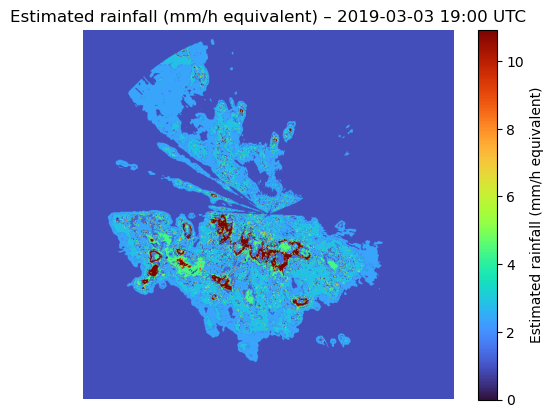

In [62]:
rain_map_10 = generate_rainfall_map_from_model(
    model_path="outputs_with_elevation/models/model_rgb_elev_id10.joblib",
    radar_dir="../../data/radar_sumare",
    elevation_grid_path="elevation_grid_sumare.npy",
    timestamp=datetime(2019, 3, 3, 19, 0),
    outputs_dir="outputs_with_elevation"
)

## Station 11

Model loaded from: outputs_with_elevation/models/model_rgb_elev_id11.joblib
Radar image loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rainfall map generated


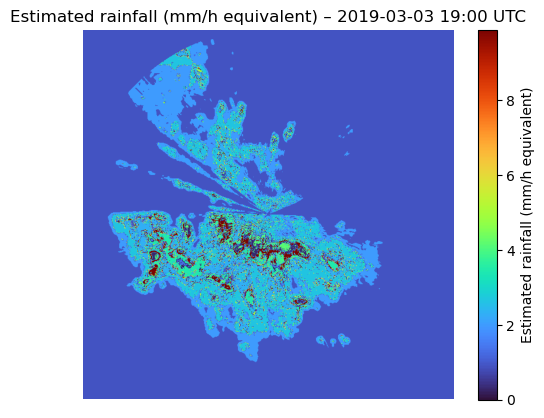

In [63]:
rain_map_11 = generate_rainfall_map_from_model(
    model_path="outputs_with_elevation/models/model_rgb_elev_id11.joblib",
    radar_dir="../../data/radar_sumare",
    elevation_grid_path="elevation_grid_sumare.npy",
    timestamp=datetime(2019, 3, 3, 19, 0),
    outputs_dir="outputs_with_elevation"
)

## Station 12

Model loaded from: outputs_with_elevation/models/model_rgb_elev_id12.joblib
Radar image loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rainfall map generated


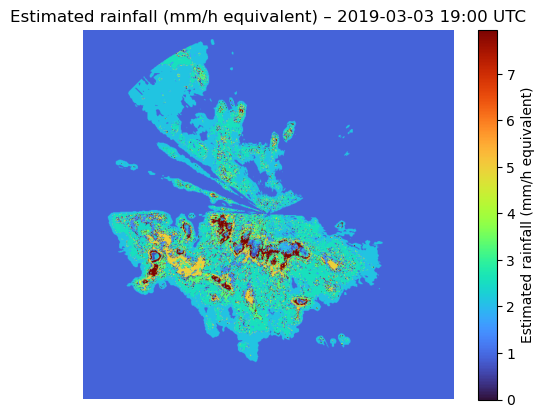

In [64]:
rain_map_12 = generate_rainfall_map_from_model(
    model_path="outputs_with_elevation/models/model_rgb_elev_id12.joblib",
    radar_dir="../../data/radar_sumare",
    elevation_grid_path="elevation_grid_sumare.npy",
    timestamp=datetime(2019, 3, 3, 19, 0),
    outputs_dir="outputs_with_elevation"
)

## Station 13

Model loaded from: outputs_with_elevation/models/model_rgb_elev_id13.joblib
Radar image loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rainfall map generated


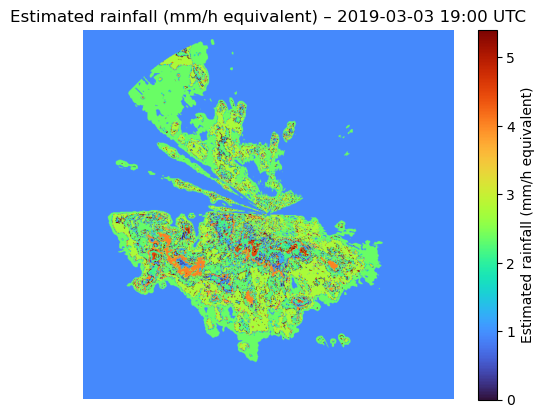

In [67]:
rain_map_13 = generate_rainfall_map_from_model(
    model_path="outputs_with_elevation/models/model_rgb_elev_id13.joblib",
    radar_dir="../../data/radar_sumare",
    elevation_grid_path="elevation_grid_sumare.npy",
    timestamp=datetime(2019, 3, 3, 19, 0),
    outputs_dir="outputs_with_elevation"
)

## Station 14

Model loaded from: outputs_with_elevation/models/model_rgb_elev_id14.joblib
Radar image loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rainfall map generated


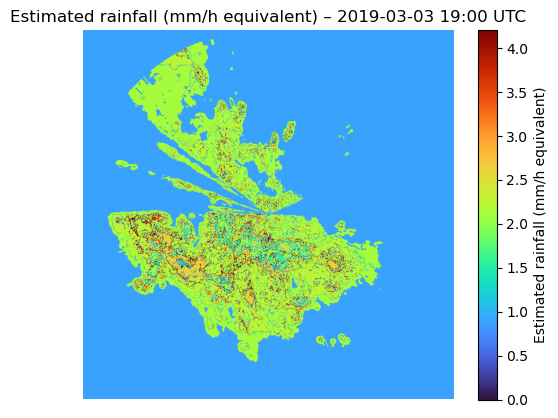

In [66]:
rain_map_14 = generate_rainfall_map_from_model(
    model_path="outputs_with_elevation/models/model_rgb_elev_id14.joblib",
    radar_dir="../../data/radar_sumare",
    elevation_grid_path="elevation_grid_sumare.npy",
    timestamp=datetime(2019, 3, 3, 19, 0),
    outputs_dir="outputs_with_elevation"
)

## Plot comparando

In [74]:
from datetime import datetime
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt


def plot_validation_single_station(
    rgb_image,
    rain_map,
    station_id,
    station_lat,
    station_lon,
    lat_grid,
    lon_grid,
    outputs_dir,
    title="",
    filename=None,
    rain_obs=None
):
    """
    Plot a side-by-side validation figure:
    - Left: Radar RGB composite
    - Right: Estimated rainfall map
    - Overlay ONE station on the rainfall map
    - Show observed vs predicted at that station
    """

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax1, ax2 = axes

    # Left: Radar RGB
    ax1.imshow(rgb_image.astype(np.uint8))
    ax1.set_title("Radar RGB (maximum reflectivity)")
    ax1.axis("off")

    # Right: Rain map
    vmax = np.nanpercentile(rain_map, 99)  # avoids extreme max ruining colorscale
    im = ax2.imshow(rain_map, cmap="turbo", vmin=0, vmax=vmax)
    ax2.set_title("Estimated rainfall (mm/h equivalent)")
    ax2.axis("off")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    # Station pixel location
    r, c = latlon_to_pixel(station_lat, station_lon, lat_grid, lon_grid)

    # Predicted value at the station pixel
    pred_mm_h = float(rain_map[r, c])

    # Plot marker
    ax2.plot(c, r, "wo", markersize=6)
    ax2.text(c + 3, r, str(int(station_id)), color="white", fontsize=9)

    # Build label: Obs vs Pred
    label_parts = []
    if rain_obs is not None:
        label_parts.append(f"Obs: {rain_obs:.2f} mm/h")
    label_parts.append(f"Pred: {pred_mm_h:.2f} mm/h")
    label = " | ".join(label_parts)

    # Put label near the station
    ax2.text(
        c + 30, r - 30,
        label,
        color="white",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.6)
    )

    if title:
        fig.suptitle(title)

    plt.tight_layout()

    if filename is None:
        filename = f"validation_station_{station_id}.png"

    out_path = os.path.join(outputs_dir, filename)
    plt.savefig(out_path, dpi=150)
    plt.show()

    print(f"Saved validation plot to: {out_path}")


def predict_and_plot_station(
    station_id,
    station_lat,
    station_lon,
    timestamp,
    model_path,
    calibration_parquet_path=None,
    radar_dir="../../data/radar_sumare",
    outputs_dir="outputs_with_elevation",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    elevation_grid_path="elevation_grid_sumare.npy",
    window_minutes=15,
    method="max"
):
    """
    Full pipeline in ONE function:
    1) Load radar RGB composite (img)
    2) Load elevation grid
    3) Build 4-feature matrix [R,G,B,elevation]
    4) Predict rainfall map (rain_map)
    5) Load lat/lon grid
    6) Plot validation for ONE chosen station
    """

    os.makedirs(outputs_dir, exist_ok=True)

    # 1) Load model
    model = joblib.load(model_path)
    print(f"Loaded model: {model_path}")

    # 2) Load radar composite -> creates 'img'
    img = load_radar_composite_15min(
        radar_dir,
        timestamp,
        window_minutes=window_minutes,
        method=method
    )

    if img is None:
        raise RuntimeError("Radar not available for this timestamp")

    print("Radar loaded:", img.shape)

    # 3) Load elevation grid
    elev_grid = np.load(elevation_grid_path)
    print("Elevation grid loaded:", elev_grid.shape)

    # 4) Build X with 4 features per pixel
    R = img[:, :, 0].reshape(-1)
    G = img[:, :, 1].reshape(-1)
    B = img[:, :, 2].reshape(-1)
    E = elev_grid.reshape(-1)

    X_pred = np.column_stack([R, G, B, E])

    # 5) Predict rainfall
    # O modelo prevê na unidade original de treino: mm/15min
    rain_flat_m15 = np.expm1(model.predict(X_pred))
    rain_map_m15 = rain_flat_m15.reshape(img.shape[:2])

    # Conversão para mm/h equivalente
    rain_map = rain_map_m15 * 4

    print("Rain map generated:", rain_map.shape)

    # 6) Load lat/lon grid
    latlon = np.load(latlon_grid_path)
    lat_grid, lon_grid = latlon["lat"], latlon["lon"]

    rain_obs = None
    if calibration_parquet_path is not None:
        df_obs = pd.read_parquet(calibration_parquet_path)
        df_obs["timestamp"] = pd.to_datetime(df_obs["timestamp"], utc=True)

        ts = pd.to_datetime(timestamp, utc=True)

        row = df_obs[df_obs["timestamp"] == ts]

        if not row.empty:
            # m15 está em mm/15min, então converte para mm/h equivalente
            rain_obs = float(row.iloc[0]["m15"]) * 4

    # 7) Plot station validation
    plot_validation_single_station(
        rgb_image=img,
        rain_map=rain_map,
        station_id=station_id,
        station_lat=station_lat,
        station_lon=station_lon,
        lat_grid=lat_grid,
        lon_grid=lon_grid,
        outputs_dir=outputs_dir,
        title=f"Station {station_id} - {timestamp:%Y-%m-%d %H:%M UTC}",
        filename=f"validation_station_{station_id}_{timestamp:%Y%m%d_%H%M}.png",
        rain_obs=rain_obs,
    )

    return img, rain_map


## Station 10

In [72]:
df = pd.read_parquet("outputs_with_elevation/parquet/calibration_station_10_with_zeros.parquet")
df.head()

,timestamp,station_id,R,G,B,elevation_m,m15
0,2012-05-21 20:45:00+00:00,10,0,0,0,80.0,0.0
1,2012-05-21 21:00:00+00:00,10,0,0,0,80.0,0.0
2,2012-05-21 21:15:00+00:00,10,0,0,0,80.0,0.0
3,2012-05-21 21:30:00+00:00,10,0,0,0,80.0,0.0
4,2012-05-21 21:45:00+00:00,10,0,0,0,80.0,0.0


Loaded model: outputs_with_elevation/models/model_rgb_elev_id10.joblib
Radar loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rain map generated: (654, 656)


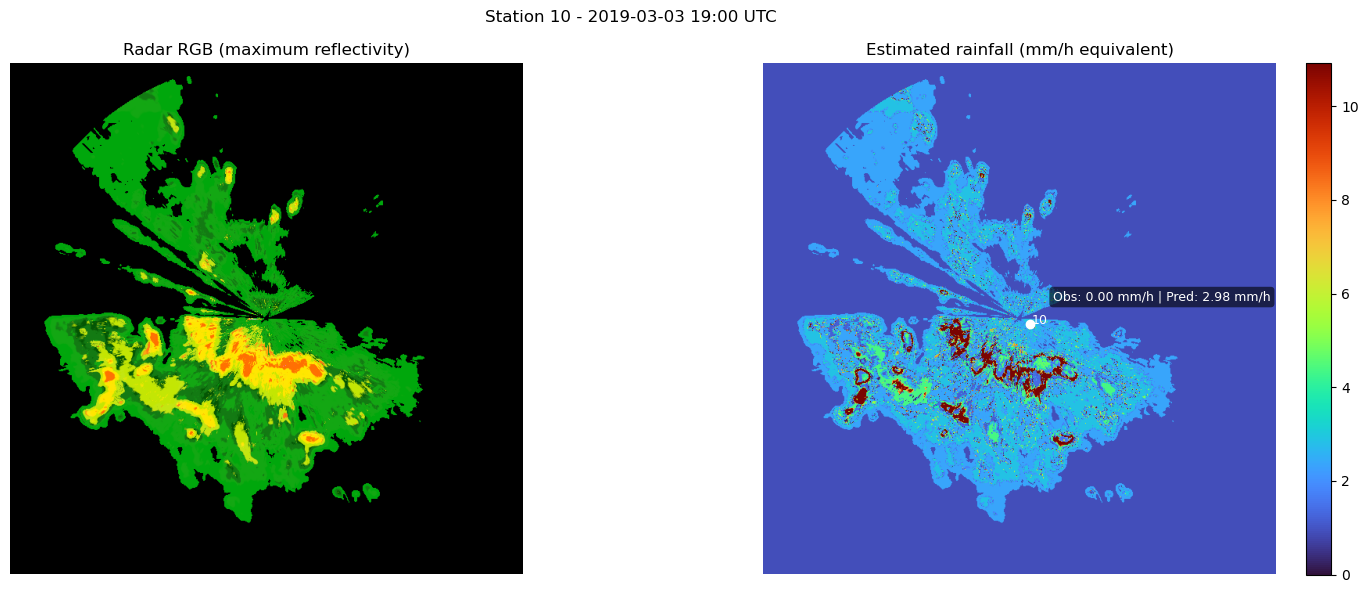

Saved validation plot to: outputs_with_elevation/validation_station_10_20190303_1900.png


In [75]:
timestamp = datetime(2019, 3, 3, 19, 0)

img_10, rain_map_10 = predict_and_plot_station(
    station_id=10,
    station_lat=-22.9808,
    station_lon=-43.1969,
    timestamp=timestamp,
    model_path="outputs_with_elevation/models/model_rgb_elev_id10.joblib",
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_10_with_zeros.parquet"
)


## Station 11

Loaded model: outputs_with_elevation/models/model_rgb_elev_id11.joblib
Radar loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rain map generated: (654, 656)


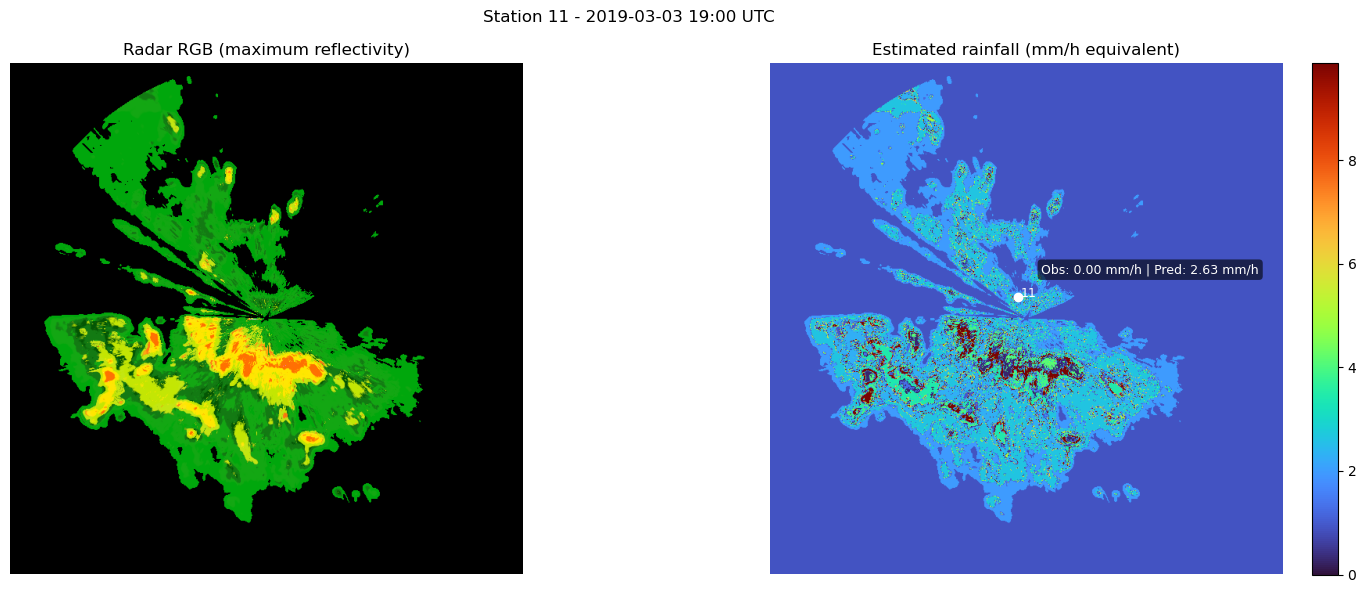

Saved validation plot to: outputs_with_elevation/validation_station_11_20190303_1900.png


In [76]:
timestamp = datetime(2019, 3, 3, 19, 0)

img_11, rain_map_11 = predict_and_plot_station(
    station_id=11,
    station_lat=-22.8443,
    station_lon=-43.2905,
    timestamp=timestamp,
    model_path="outputs_with_elevation/models/model_rgb_elev_id11.joblib",
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_11_with_zeros.parquet"
)


## Station 12

Loaded model: outputs_with_elevation/models/model_rgb_elev_id12.joblib
Radar loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rain map generated: (654, 656)


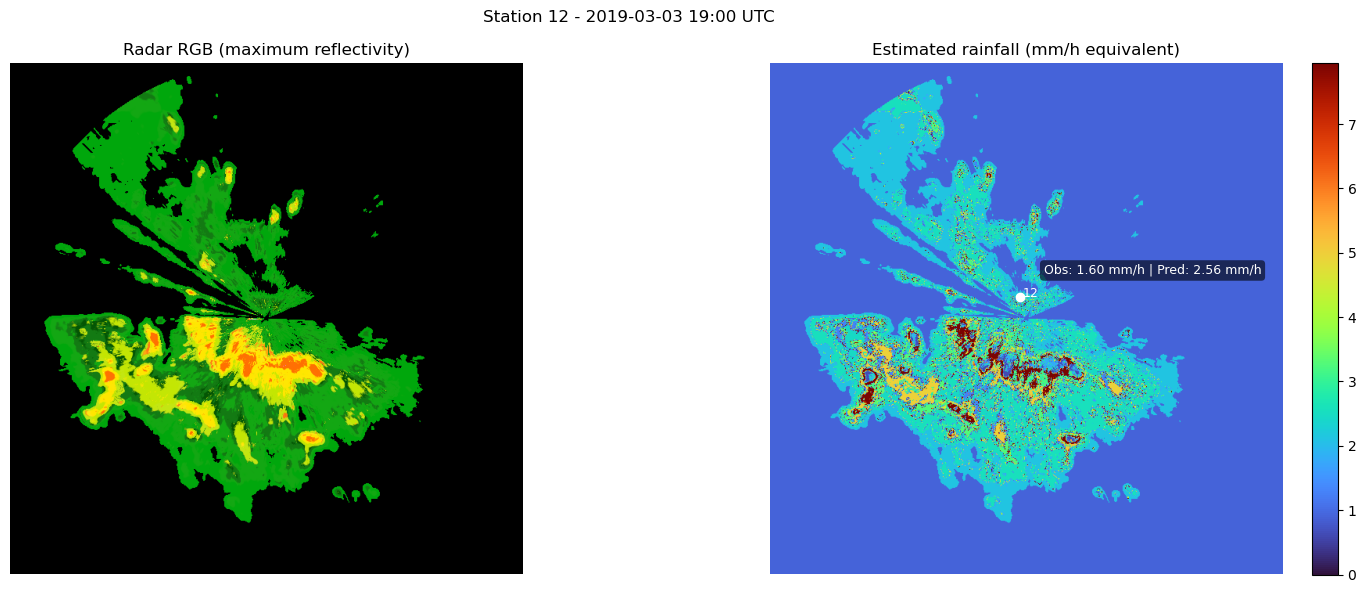

Saved validation plot to: outputs_with_elevation/validation_station_12_20190303_1900.png


In [77]:
timestamp = datetime(2019, 3, 3, 19, 0)

img_12, rain_map_12 = predict_and_plot_station(
    station_id=12,
    station_lat=-22.8483,
    station_lon=-43.2805,
    timestamp=timestamp,
    model_path="outputs_with_elevation/models/model_rgb_elev_id12.joblib",
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_12_with_zeros.parquet"
)


## Station 13

Loaded model: outputs_with_elevation/models/model_rgb_elev_id13.joblib
Radar loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rain map generated: (654, 656)


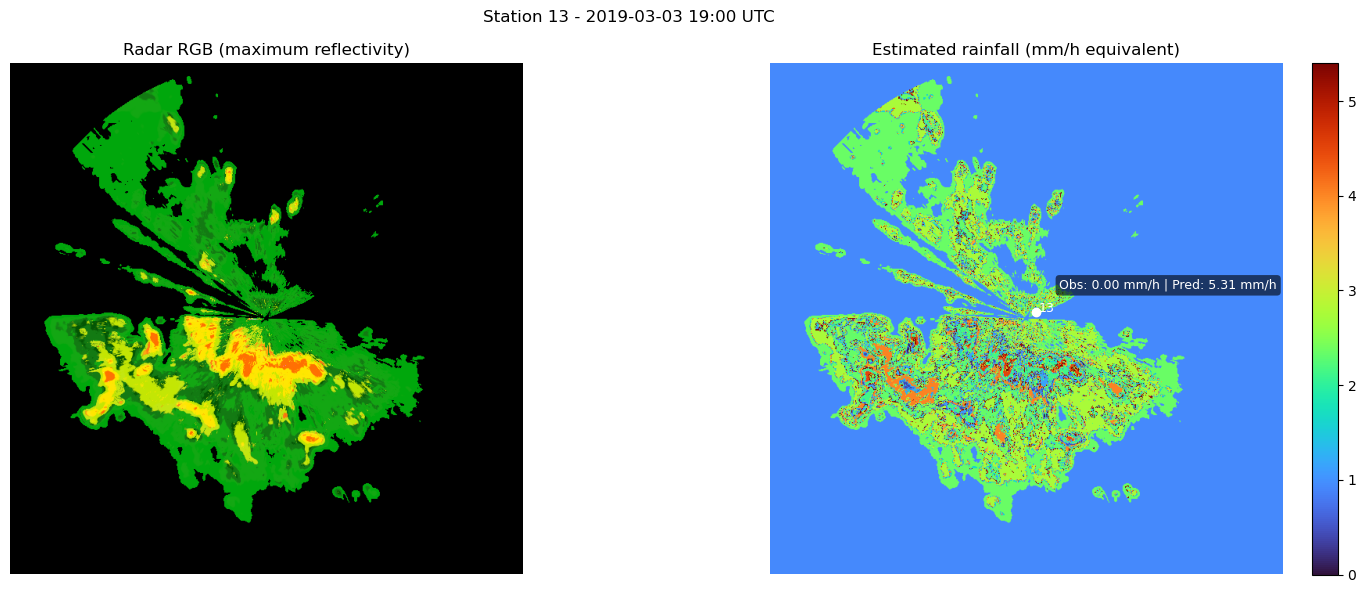

Saved validation plot to: outputs_with_elevation/validation_station_13_20190303_1900.png


In [78]:
timestamp = datetime(2019, 3, 3, 19, 0)

img_13, rain_map_13 = predict_and_plot_station(
    station_id=13,
    station_lat=-22.9214,
    station_lon=-43.1967, 
    timestamp=timestamp,
    model_path="outputs_with_elevation/models/model_rgb_elev_id13.joblib",
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_13_with_zeros.parquet"
)


## Station 14

Loaded model: outputs_with_elevation/models/model_rgb_elev_id14.joblib
Radar loaded: (654, 656, 3)
Elevation grid loaded: (654, 656)
Rain map generated: (654, 656)


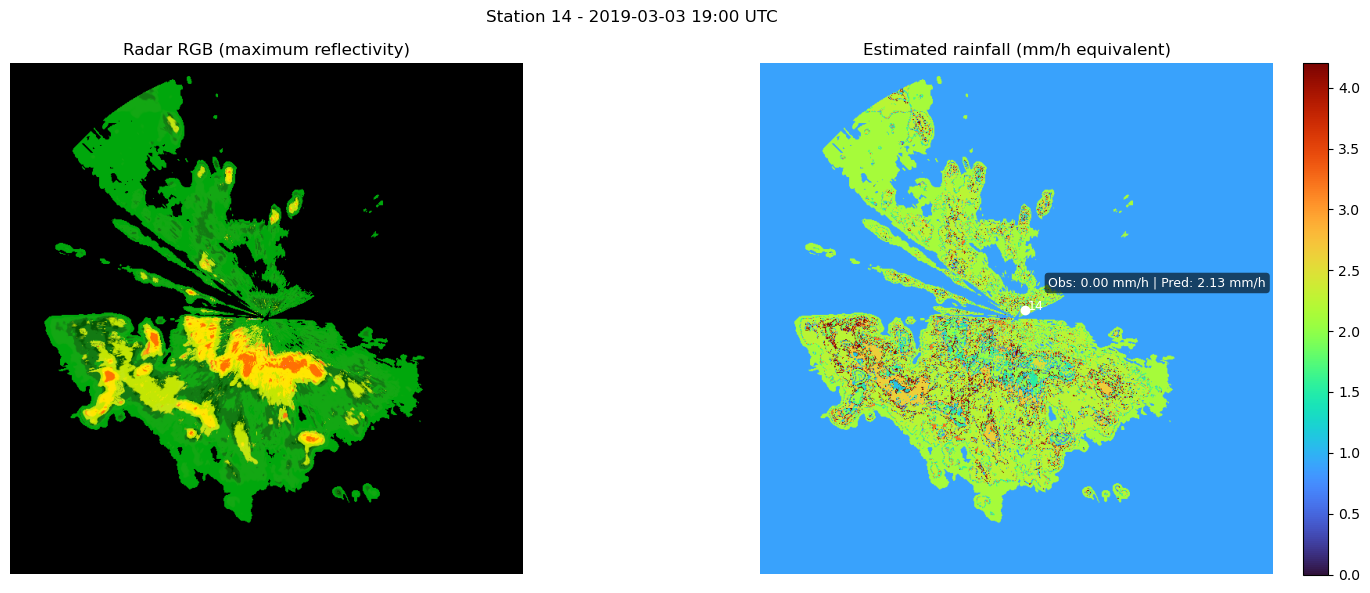

Saved validation plot to: outputs_with_elevation/validation_station_14_20190303_1900.png


In [79]:
timestamp = datetime(2019, 3, 3, 19, 0)

img_14, rain_map_14 = predict_and_plot_station(
    station_id=14,
    station_lat=-22.9122,
    station_lon=-43.2038, 
    timestamp=timestamp,
    model_path="outputs_with_elevation/models/model_rgb_elev_id14.joblib",
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_14_with_zeros.parquet"
)


## TABELAS texto tcc

In [80]:
def create_tcc_validation_table_single_station(
    img,
    rain_map,
    station_id,
    station_lat,
    station_lon,
    timestamp,
    calibration_parquet_path,
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
):
    """
    Cria uma tabela simples para o TCC com:
    - Data/Hora
    - Estação
    - RGB do radar
    - valor medido
    - valor previsto

    Observação:
    - rain_map deve estar em mm/h equivalente.
    - m15 do parquet está em mm/15min e será convertido para mm/h.
    """

    # Carrega grade de latitude/longitude
    latlon = np.load(latlon_grid_path)
    lat_grid, lon_grid = latlon["lat"], latlon["lon"]

    # Encontra o pixel correspondente à estação
    r, c = latlon_to_pixel(station_lat, station_lon, lat_grid, lon_grid)

    # RGB do radar no pixel da estação
    R = int(img[r, c, 0])
    G = int(img[r, c, 1])
    B = int(img[r, c, 2])

    rgb_value = f"({R}, {G}, {B})"

    # Valor previsto no ponto da estação
    # Aqui assume que rain_map já está em mm/h equivalente
    rain_pred_mm_h = float(rain_map[r, c])

    # Lê o valor observado
    df_obs = pd.read_parquet(calibration_parquet_path)
    df_obs["timestamp"] = pd.to_datetime(df_obs["timestamp"], utc=True)

    ts = pd.to_datetime(timestamp, utc=True)

    mask = df_obs["timestamp"] == ts

    if "station_id" in df_obs.columns:
        mask = mask & (df_obs["station_id"].astype(str) == str(station_id))

    row = df_obs[mask]

    if row.empty:
        rain_obs_mm_h = np.nan
    else:
        rain_obs = float(row.iloc[0][obs_col])

        # m15 está em mm/15min, então converte para mm/h equivalente
        if obs_is_15min:
            rain_obs_mm_h = rain_obs * 4
        else:
            rain_obs_mm_h = rain_obs

    # Tabela final para copiar no TCC
    tcc_table = pd.DataFrame([{
        "Data/Hora (UTC)": ts.strftime("%d/%m/%Y %H:%M"),
        "Estação": station_id,
        "RGB do radar": rgb_value,
        "Medido (mm/h equiv.)": rain_obs_mm_h,
        "Previsto (mm/h equiv.)": rain_pred_mm_h
    }])

    # Arredonda valores
    tcc_table["Medido (mm/h equiv.)"] = tcc_table["Medido (mm/h equiv.)"].round(2)
    tcc_table["Previsto (mm/h equiv.)"] = tcc_table["Previsto (mm/h equiv.)"].round(2)

    print("\nTabela para o TCC:")
    print(tcc_table.to_string(index=False))

    return tcc_table

## estação 10

In [82]:
tabela_10 = create_tcc_validation_table_single_station(
    img=img_10,
    rain_map=rain_map_10,
    station_id=10,
    station_lat=-22.9808,  
    station_lon=-43.1969,
    timestamp=timestamp,
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_10_with_zeros.parquet",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
)


Tabela para o TCC:
 Data/Hora (UTC)  Estação  RGB do radar  Medido (mm/h equiv.)  Previsto (mm/h equiv.)
03/03/2019 19:00       10 (19, 125, 19)                   0.0                    2.98


## estação 11

In [83]:
tabela_11 = create_tcc_validation_table_single_station(
    img=img_11,
    rain_map=rain_map_11,
    station_id=11,
    station_lat=-22.8443,  
    station_lon=-43.2905,
    timestamp=timestamp,
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_11_with_zeros.parquet",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
)


Tabela para o TCC:
 Data/Hora (UTC)  Estação  RGB do radar  Medido (mm/h equiv.)  Previsto (mm/h equiv.)
03/03/2019 19:00       11 (19, 167, 19)                   0.0                    2.63


## estação 12

In [84]:
tabela_12 = create_tcc_validation_table_single_station(
    img=img_12,
    rain_map=rain_map_12,
    station_id=12,
    station_lat=-22.8483,  
    station_lon=-43.2805,
    timestamp=timestamp,
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_12_with_zeros.parquet",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
)


Tabela para o TCC:
 Data/Hora (UTC)  Estação  RGB do radar  Medido (mm/h equiv.)  Previsto (mm/h equiv.)
03/03/2019 19:00       12 (19, 167, 19)                   1.6                    2.56


## estação 13

In [85]:
tabela_13 = create_tcc_validation_table_single_station(
    img=img_13,
    rain_map=rain_map_13,
    station_id=13,
    station_lat=-22.9214,  
    station_lon=-43.1967,
    timestamp=timestamp,
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_13_with_zeros.parquet",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
)


Tabela para o TCC:
 Data/Hora (UTC)  Estação  RGB do radar  Medido (mm/h equiv.)  Previsto (mm/h equiv.)
03/03/2019 19:00       13 (11, 167, 12)                   0.0                    5.31


## estação 14

In [86]:
tabela_14 = create_tcc_validation_table_single_station(
    img=img_14,
    rain_map=rain_map_14,
    station_id=14,
    station_lat=-22.9122,  
    station_lon=-43.2038,
    timestamp=timestamp,
    calibration_parquet_path="outputs_with_elevation/parquet/calibration_station_14_with_zeros.parquet",
    latlon_grid_path="sumare_radar_latlon_grid.npz",
    obs_col="m15",
    obs_is_15min=True
)


Tabela para o TCC:
 Data/Hora (UTC)  Estação  RGB do radar  Medido (mm/h equiv.)  Previsto (mm/h equiv.)
03/03/2019 19:00       14 (141, 188, 2)                   0.0                    2.13


## feature importance

/tmp/ipykernel_1602/1251888973.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


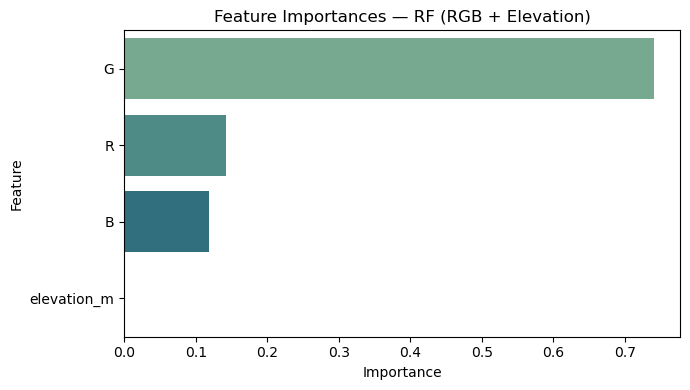

Figure saved at: outputs_with_elevation/feature_importance_rf_station12_rgb_dem.png


In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# carregar modelo
model_path = "outputs_with_elevation/models/model_rgb_elev_id12.joblib"
reg = joblib.load(model_path)

feature_names = ["R", "G", "B", "elevation_m"]

# feature importance
reg_importances = (
    pd.Series(reg.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
)

# diretório de saída
output_dir = "outputs_with_elevation/"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "feature_importance_rf_station12_rgb_dem.png"
)

# plot
plt.figure(figsize=(7, 4))
sns.barplot(
    x=reg_importances.values,
    y=reg_importances.index,
    palette="crest"
)

plt.title("Feature Importances — RF (RGB + Elevation)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

# salvar
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved at: {output_path}")


## analise exploratoria

In [ ]:
import os

eda_dir = "outputs_with_elevation/eda_plots"
os.makedirs(eda_dir, exist_ok=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# exemplo: estação 10 já carregada
df = pd.read_parquet("outputs_with_elevation/calibration_station_10_with_zeros.parquet")

In [ ]:
df.info()

In [ ]:
df[["R", "G", "B", "elevation_m", "m15"]].describe()

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["m15"], bins=100)
plt.yscale("log")
plt.xlabel("Rainfall (mm / 15 min)")
plt.ylabel("Frequency (log scale)")
plt.title("Observed rainfall distribution (WebSirene)")
plt.tight_layout()
plt.savefig(
    os.path.join(eda_dir, "rainfall_distribution_log_frequency.png"),
    dpi=150
)
plt.show()

In [ ]:
df["rain_binary"] = (df["m15"] > 0.1).astype(int)

plt.figure(figsize=(4,4))
sns.countplot(x="rain_binary", data=df)
plt.xlabel("Class (0 = no rain, 1 = rain)")
plt.ylabel("Number of samples")
plt.title("Binary rainfall distribution")
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, ch in zip(axes, ["R", "G", "B"]):
    ax.hist(df[ch], bins=50)
    ax.set_title(f"{ch} channel")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Frequency")

plt.suptitle("Radar reflectivity value distributions (RGB)")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["elevation_m"], bins=50)
plt.xlabel("Elevation (m)")
plt.ylabel("Frequency")
plt.title("Elevation distribution (Digital Elevation Model)")
plt.tight_layout()
plt.show()

In [ ]:
corr = df[["R", "G", "B", "elevation_m", "m15"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix between radar, elevation and rainfall")
plt.tight_layout()
plt.show()

## testando

In [50]:
def load_all_websirene_stations(base_dir):
    stations = []

    station_dirs = sorted(glob.glob(os.path.join(base_dir, "station_id=*")))

    for station_path in station_dirs:
        station_id = int(station_path.split("=")[-1])

        year_files = glob.glob(os.path.join(station_path, "year=*/data.parquet"))
        if not year_files:
            continue

        # lê só o primeiro arquivo (lat/lon é fixo)
        df = pd.read_parquet(year_files[0])

        lat = df.iloc[0]["latitude"]
        lon = df.iloc[0]["longitude"]

        stations.append({
            "station_id": station_id,
            "latitude": lat,
            "longitude": lon
        })

    return pd.DataFrame(stations)


In [51]:
def filter_stations_within_radar(stations_df):
    mask = stations_df.apply(
        lambda row: is_within_radius(
            row["latitude"],
            row["longitude"],
            SUMARE_RADAR_LAT,
            SUMARE_RADAR_LON,
            SUMARE_RADAR_RADIUS
        ),
        axis=1
    )
    return stations_df[mask].reset_index(drop=True)


In [52]:
import matplotlib.pyplot as plt

def plot_stations_on_radar(radar_img, stations_df, lat_grid, lon_grid):
    plt.figure(figsize=(10, 10))
    plt.imshow(radar_img)
    plt.axis("off")

    for _, row in stations_df.iterrows():
        r, c = latlon_to_pixel(
            row["latitude"],
            row["longitude"],
            lat_grid,
            lon_grid
        )

        plt.scatter(c, r, s=40, color="red")
        plt.text(c + 4, r - 4, str(row["station_id"]),
                 color="white", fontsize=8, weight="bold")

    plt.title("Estações WebSirene dentro do alcance do Radar do Sumaré")
    plt.show()


In [53]:
def plot_all_websirene_stations_on_radar(
    base_dir,
    radar_dir,
    grid_file,
    dt_utc
):
    # carrega radar
    radar_img = load_radar_composite_15min(
        radar_dir,
        dt_utc,
        window_minutes=15,
        method="max"
    )

    if radar_img is None:
        print("❌ Radar não disponível nesse horário")
        return

    # carrega grid
    latlon = np.load(grid_file)
    lat_grid, lon_grid = latlon["lat"], latlon["lon"]

    # carrega todas as estações
    stations = load_all_websirene_stations(base_dir)
    print(f"Total de estações WebSirene: {len(stations)}")

    # filtra pelo alcance do radar
    stations_in_range = filter_stations_within_radar(stations)
    print(f"Estações dentro do alcance do radar: {len(stations_in_range)}")

    # Imprimir os IDs das estações dentro do alcance
    print("\nIDs das estações dentro do alcance do radar:")
    for idx, row in stations_in_range.iterrows():
        print(f"Estação ID: {row['station_id']} - Latitude: {row['latitude']}, Longitude: {row['longitude']}")

    # plota
    plot_stations_on_radar(radar_img, stations_in_range, lat_grid, lon_grid)


Total de estações WebSirene: 83
Estações dentro do alcance do radar: 83

IDs das estações dentro do alcance do radar:
Estação ID: 1.0 - Latitude: -22.8636, Longitude: -43.2636
Estação ID: 10.0 - Latitude: -22.9808, Longitude: -43.1969
Estação ID: 11.0 - Latitude: -22.8443, Longitude: -43.2905
Estação ID: 12.0 - Latitude: -22.8483, Longitude: -43.2805
Estação ID: 13.0 - Latitude: -22.9214, Longitude: -43.1967
Estação ID: 14.0 - Latitude: -22.9122, Longitude: -43.2038
Estação ID: 15.0 - Latitude: -22.9901, Longitude: -43.2325
Estação ID: 16.0 - Latitude: -22.9263, Longitude: -43.2196
Estação ID: 17.0 - Latitude: -22.9605, Longitude: -43.1679
Estação ID: 18.0 - Latitude: -22.9017, Longitude: -43.3594
Estação ID: 19.0 - Latitude: -22.9178, Longitude: -43.2817
Estação ID: 2.0 - Latitude: -22.8547, Longitude: -43.2725
Estação ID: 20.0 - Latitude: -22.8711, Longitude: -43.2894
Estação ID: 21.0 - Latitude: -22.9324, Longitude: -43.2012
Estação ID: 22.0 - Latitude: -22.89, Longitude: -43.3439
E

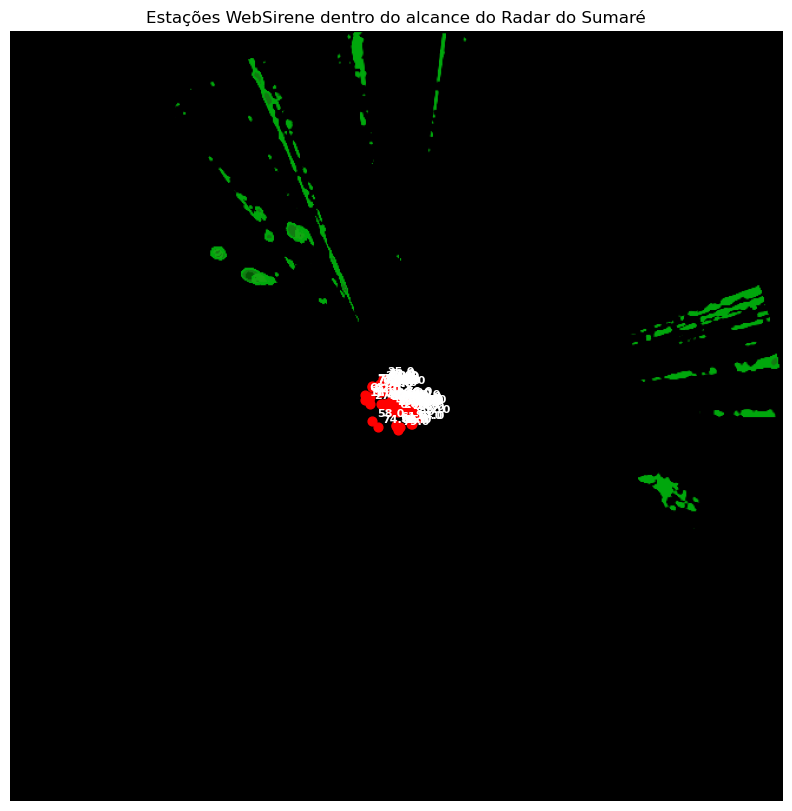

In [54]:
plot_all_websirene_stations_on_radar(
    base_dir="../../data/ws/full",
    radar_dir="../../data/radar_sumare",
    grid_file="sumare_radar_latlon_grid.npz",
    dt_utc=pd.Timestamp("2024-01-01 12:00", tz="UTC")
)
